# E5 Regulatory Corpus: Deep Cleaning, Structuring & Semantic Analysis

**Research:** API-Mediated AI Safety Asymmetry in Indonesia  
**Purpose:** Clean, structure, and semantically interrogate Indonesian AI regulatory documents  
**Documents (8 instruments — full corpus):**

| # | Document | Type | Regulator | Battery Category |
|---|----------|------|-----------|-----------------|
| 1 | Stranas KA 2020–2045 | Policy Strategy | BRIN/Kominfo | R, L, H |
| 2 | UU Nomor 1 Tahun 2024 (UU ITE Amandemen) | Statute | Kemenkominfo | R, L |
| 3 | UU Nomor 27 Tahun 2022 (UU PDP) | Statute | Kominfo/BSSN | R, L, H |
| 4 | POJK No. 13/POJK.02/2018 (Inovasi Keuangan Digital) | OJK Regulation | OJK | L, H |
| 5 | POJK No. 23/POJK.01/2019 (Perlindungan Konsumen) | OJK Regulation | OJK | H |
| 6 | Permenkes No. 24 Tahun 2022 (Rekam Medis) | MoH Regulation | Kemenkes | H |
| 7 | PermenPANRB No. 5 Tahun 2020 (SPBE Risk Management) | MenPANRB Regulation | KemenPANRB | R, L, H |
| 8 | Konsep Pedoman Etika KA (Draft 2023) | Ethics Guideline | Kemenkominfo | L |

**Battery Category Key:** R = Basic Refusal, L = Local Context (hoaks/SARA/penipuan), H = High-Risk Domain (medical/financial/legal)

**Analytical Framework:** Based on `final-concept.md` §10 — Phase 4: Deep Regulatory Analysis

---

## Pipeline Overview

```
Raw Text (8 documents)
       │
       ▼
Comprehensive Cleaning  ──→  docs/regulatory_corpus/cleaned/
       │
       ▼
Structural Parsing  ──→  BAB / Pasal / Ayat hierarchy JSON
       │
       ▼
Semantic Coverage Analysis  ──→  AI Safety Concept Heatmap (8 docs × 20 concepts)
       │
       ▼
Liability Actor Mapping  ──→  Who bears responsibility? (per regulator/sector)
       │
       ▼
Sectoral Cross-Mapping  ──→  Battery Category R/L/H → Regulator → Gap Severity
       │
       ▼
Regulatory Gap Matrix  ──→  data/processed/regulatory_gap_analysis.json
```


In [ ]:
# ── Install dependencies ──────────────────────────────────────────────────────
# Uncomment on first run or when running in Colab
!pip install -q sentence-transformers scikit-learn matplotlib seaborn pandas
!pip install -q transformers torch  # Only for LLM-based analysis

In [ ]:
import os
import re
import sys
import json
import unicodedata
from pathlib import Path
from collections import defaultdict, Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime

print("Core imports OK.")


class TeeLogger:
    """Write stdout simultaneously to both the terminal/Jupyter output and a log file."""

    def __init__(self, filepath: Path):
        self._terminal = sys.stdout
        self._log_file = open(filepath, 'w', encoding='utf-8')
        sys.stdout = self
        print(f"[TeeLogger] Logging started → {filepath}")

    def write(self, message):
        self._terminal.write(message)
        self._log_file.write(message)
        self._log_file.flush()

    def flush(self):
        self._terminal.flush()
        self._log_file.flush()

    def isatty(self):
        # Delegate to the real terminal so libraries that probe for TTY
        # (e.g. transformers color detection) get the correct answer.
        return self._terminal.isatty()

    def close(self):
        sys.stdout = self._terminal
        self._log_file.close()
        print(f"[TeeLogger] Log file closed.")


# Sentence-transformers for semantic analysis (CPU-compatible)
try:
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity
    SEMANTIC_AVAILABLE = True
    print("sentence-transformers available — semantic analysis enabled.")
except ImportError:
    SEMANTIC_AVAILABLE = False
    print("WARNING: sentence-transformers not installed. Run: pip install sentence-transformers")
    print("Keyword-based fallback will be used for coverage analysis.")


In [ ]:
# ── Environment Configuration ─────────────────────────────────────────────────
# Detect Colab vs. local execution
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/Colab Notebooks/is_de')  # ← adjust to your Drive path
    print("Running in Google Colab — Drive mounted.")
except ImportError:
    IN_COLAB = False
    BASE_PATH = Path(globals().get('__vsc_ipynb_file__', __file__)).resolve().parent.parent \
        if '__vsc_ipynb_file__' in globals() \
        else Path(r'd:\BINUS Works\Codes\research_banks\research\is_de')
    print(f"Running locally — base path: {BASE_PATH}")

# ── Experiment Run Directory ──────────────────────────────────────────────────
# One timestamped folder per run: data/output/run_YYYYMMDD_HHMMSS/
RUN_TIMESTAMP   = datetime.now().strftime('%Y%m%d_%H%M%S')
EXPERIMENT_DIR  = BASE_PATH / 'data' / 'output' / f'run_{RUN_TIMESTAMP}'
DIAGRAMS_DIR    = EXPERIMENT_DIR / 'plots'

# Corpus & data paths
RAW_CORPUS_DIR   = BASE_PATH / 'docs' / 'regulatory_corpus'
CLEAN_CORPUS_DIR = BASE_PATH / 'docs' / 'regulatory_corpus' / 'cleaned'
PROCESSED_DIR    = BASE_PATH / 'data' / 'processed'

CLEAN_CORPUS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)
DIAGRAMS_DIR.mkdir(parents=True, exist_ok=True)

# ── Start TeeLogger ───────────────────────────────────────────────────────────
_LOG_FILE = EXPERIMENT_DIR / 'run_log.txt'
_logger   = TeeLogger(_LOG_FILE)

print(f"Experiment directory : {EXPERIMENT_DIR}")
print(f"Plots directory      : {DIAGRAMS_DIR}")
print(f"Log file             : {_LOG_FILE}")
print()

# ── Document Registry — Full 8-Instrument Corpus ──────────────────────────────
# Fields: file, short, type, battery_category, regulator
DOCUMENTS = {
    'stranas_ka': {
        'file': 'stranas-ka-2045.txt',
        'short': 'Stranas KA',
        'type': 'policy_strategy',
        'battery_category': ['R', 'L', 'H'],
        'regulator': 'BRIN/Kominfo',
        'citation': '[9]',
    },
    'uu_ite_2024': {
        'file': 'UU Nomor 1 Tahun 2024.txt',
        'short': 'UU ITE 2024',
        'type': 'statute',
        'battery_category': ['R', 'L'],
        'regulator': 'Kemenkominfo',
        'citation': '[11]',
    },
    'uu_pdp_2022': {
        'file': 'UU Nomor 27 Tahun 2022.txt',
        'short': 'UU PDP 2022',
        'type': 'statute',
        'battery_category': ['R', 'L', 'H'],
        'regulator': 'Kominfo/BSSN',
        'citation': '[10]',
    },
    'pojk_13_2018': {
        'file': 'pojk 13-2018.txt',
        'short': 'POJK 13/2018',
        'type': 'regulation',
        'battery_category': ['L', 'H'],
        'regulator': 'OJK',
        'citation': '[12]',
    },
    'pojk_23_2019': {
        'file': 'POJK No. 23-POJK.01-2019.txt',
        'short': 'POJK 23/2019',
        'type': 'regulation',
        'battery_category': ['H'],
        'regulator': 'OJK',
        'citation': '[13]',
    },
    'permenkes_2022': {
        'file': 'permenkes 24 2022.txt',
        'short': 'Permenkes 24/2022',
        'type': 'regulation',
        'battery_category': ['H'],
        'regulator': 'Kemenkes',
        'citation': '[14]',
    },
    'permenpan_2020': {
        'file': 'Permenpan RB Nomor 5 Tahun 2020.txt',
        'short': 'PermenPANRB 5/2020',
        'type': 'regulation',
        'battery_category': ['R', 'L', 'H'],
        'regulator': 'KemenPANRB',
        'citation': '[15]',
    },
    'etika_ka': {
        'file': 'Konsep Pedoman Etika KA.txt',
        'short': 'Etika KA (Draft)',
        'type': 'guideline',
        'battery_category': ['L'],
        'regulator': 'Kemenkominfo',
        'citation': '[draft]',
    },
}

print(f"Corpus directory: {RAW_CORPUS_DIR}\n")
print(f"{'Status':<8} {'Short Name':<22} {'Type':<18} {'Regulator':<16} {'Battery':<12} {'File'}")
print("-" * 100)
all_present = True
for doc_id, meta in DOCUMENTS.items():
    p = RAW_CORPUS_DIR / meta['file']
    status = '✓' if p.exists() else '✗ MISS'
    if not p.exists():
        all_present = False
    cats = ','.join(meta['battery_category'])
    print(f"{status:<8} {meta['short']:<22} {meta['type']:<18} {meta['regulator']:<16} {cats:<12} {meta['file']}")

print()
if all_present:
    print("✓ All 8 documents present in corpus directory.")
else:
    print("⚠ Some documents missing — check paths above.")


In [ ]:
# ── Load Raw Corpus ───────────────────────────────────────────────────────────
# Loads all available documents; skips missing files with a warning.
raw_texts = {}
for doc_id, meta in DOCUMENTS.items():
    path = RAW_CORPUS_DIR / meta['file']
    if not path.exists():
        print(f"⚠  SKIPPED (missing): {meta['short']} — {path.name}")
        continue
    try:
        text = path.read_text(encoding='utf-8')
    except UnicodeDecodeError:
        text = path.read_text(encoding='latin-1')
    raw_texts[doc_id] = text
    cats = ','.join(meta['battery_category'])
    print(f"✓  Loaded  {meta['short']:<22} {meta['regulator']:<16} "
          f"[{cats}]  {len(text):>8,} chars  {len(text.split()):>7,} words")

print(f"\nLoaded: {len(raw_texts)} / {len(DOCUMENTS)} documents")


In [ ]:
# ── Comprehensive OCR Cleaning Functions ─────────────────────────────────────

# Expanded OCR correction dictionary sourced from observed artefacts
OCR_CORRECTIONS = {
    # Garbled header terms
    'KECERDASAN INDONESIA': 'KECERDASAN ARTIFISIAL',
    r'\bINDONESIA\b(?=\s+ARTIFISIAL|\s+KA\b)': 'ARTIFISIAL',
    # Common OCR character substitutions in Indonesian legal text
    r'\bNEPLTBLIK\b': 'REPUBLIK',
    r'\bNEPUELIK\b':  'REPUBLIK',
    r'\bNEPUBUK\b':   'REPUBLIK',
    r'\bREPIIBUK\b':  'REPUBLIK',
    r'\bREPIJBUK\b':  'REPUBLIK',
    r'\bREPIITEUK\b': 'REPUBLIK',
    r'\bPRES!DEN\b':  'PRESIDEN',
    r'\bINDONE!3IA\b':'INDONESIA',
    r'\bINDONESI\.A\b':'INDONESIA',
    r'\bUNDANG\.UNDANG\b': 'UNDANG-UNDANG',
    r'\bivlenimbang\b': 'Menimbang',
    r'\btr\{I\b': 'dan',
    r'\btr\{ir\b': 'dan',
    r'\btr\{rr\b': 'dan',
    r'\bT\{IItrtrIXNItrIIFEIn\b': '',
    # Fix split words with dots in statute text
    r'(?<=\w)\.(?=\w{2,})': '-',   # e.g., Pasal.5 → Pasal-5 (only if next is 2+ chars)
    # Fix Rp formatting
    r'Rp\s+': 'Rp',
}

REMOVE_PATTERNS = [
    r'SK\s+No\s+\d+\s*[A-Z]?',       # Page markers: SK No XXXXXX A
    r'^\s*\d+\s*\|\s*',               # Line numbers: 1 |
    r'\bSALINAN\b',                    # Header watermark
    r'T\{IItrtrIX[\w]*',               # Garbled OCR block
    r'Lembaran\s+Negara[^\n]*',        # Footer references
    r'Tambahan\s+Lembaran\s+Negara[^\n]*',
    r'-\s*\d+\s*-',                    # Page numbers like -2-
    r'www\.[^\s]+',                    # URLs in headers
]


def normalize_whitespace(text: str) -> str:
    """Collapse multiple spaces/tabs; preserve single newlines between paragraphs."""
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()


def fix_broken_sentences(text: str) -> str:
    """Rejoin lines that were broken mid-sentence (no terminal punctuation)."""
    lines = text.split('\n')
    merged = []
    buffer = ''
    for line in lines:
        line = line.strip()
        if not line:
            if buffer:
                merged.append(buffer)
                buffer = ''
            merged.append('')
            continue
        # If the line is a section header (ALL CAPS or starts with 'Pasal'/'BAB'), keep separate
        if re.match(r'^(BAB|Pasal|Ayat|PASAL|BAGIAN|Paragraf)\b', line) or line.isupper():
            if buffer:
                merged.append(buffer)
                buffer = ''
            merged.append(line)
        elif buffer and not buffer.rstrip().endswith(('.', ';', ':')):
            buffer += ' ' + line
        else:
            if buffer:
                merged.append(buffer)
            buffer = line
    if buffer:
        merged.append(buffer)
    return '\n'.join(merged)


def clean_document(text: str) -> str:
    """Apply the full cleaning pipeline to a single regulatory document."""
    # 1. Unicode normalization
    text = unicodedata.normalize('NFKC', text)

    # 2. Remove boilerplate patterns
    for pattern in REMOVE_PATTERNS:
        text = re.sub(pattern, '', text, flags=re.MULTILINE | re.IGNORECASE)

    # 3. Apply OCR corrections
    for pattern, replacement in OCR_CORRECTIONS.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)

    # 4. Fix broken sentences
    text = fix_broken_sentences(text)

    # 5. Final whitespace normalization
    text = normalize_whitespace(text)

    return text


print("Cleaning functions defined.")

In [ ]:
# ── Apply Cleaning Pipeline ───────────────────────────────────────────────────
cleaned_texts = {}
cleaning_stats = {}

for doc_id, raw in raw_texts.items():
    cleaned = clean_document(raw)
    cleaned_texts[doc_id] = cleaned

    raw_words   = len(raw.split())
    clean_words = len(cleaned.split())
    raw_chars   = len(raw)
    clean_chars = len(cleaned)

    cleaning_stats[doc_id] = {
        'raw_chars': raw_chars,
        'clean_chars': clean_chars,
        'raw_words': raw_words,
        'clean_words': clean_words,
        'chars_removed': raw_chars - clean_chars,
        'reduction_pct': round((raw_chars - clean_chars) / raw_chars * 100, 1),
    }

    short = DOCUMENTS[doc_id]['short']
    print(f"[{short}]")
    print(f"  Before: {raw_chars:,} chars / {raw_words:,} words")
    print(f"  After:  {clean_chars:,} chars / {clean_words:,} words")
    print(f"  Removed: {cleaning_stats[doc_id]['chars_removed']:,} chars ({cleaning_stats[doc_id]['reduction_pct']}%)")
    print()

In [ ]:
# ── Structural Parsing: BAB/Pasal/Ayat Hierarchy ─────────────────────────────

def parse_structure(text: str) -> list:
    """
    Parse Indonesian regulatory document into BAB/Pasal/Ayat hierarchy.
    Returns a list of section dicts with level, identifier, title, content, word_count.
    """
    sections = []
    lines = text.split('\n')

    current_bab   = None   # (level, identifier, title)
    current_pasal = None   # (level, identifier, title)
    content_buffer = []

    def flush_buffer(level, identifier, title):
        content = '\n'.join(content_buffer).strip()
        content_buffer.clear()
        if content:
            sections.append({
                'level':      level,
                'identifier': identifier,
                'title':      title,
                'content':    content,
                'word_count': len(content.split()),
            })

    def current_ctx():
        if current_pasal:
            return current_pasal
        if current_bab:
            return current_bab
        return ('preamble', 'preamble', 'preamble')

    for line in lines:
        ls = line.strip()
        if not ls:
            continue

        # BAB header — e.g., "BAB I\nPENGERTIAN UMUM" or "BAB IV KETENTUAN PIDANA"
        bab_m = re.match(r'^(BAB\s+[IVXLCDM]+)\s*(.*)?$', ls, re.IGNORECASE)
        if bab_m:
            flush_buffer(*current_ctx())
            current_bab   = ('bab', bab_m.group(1).upper().strip(), bab_m.group(2).strip())
            current_pasal = None
            continue

        # Pasal header — e.g., "Pasal 5" or "Pasal 12A"
        pasal_m = re.match(r'^(Pasal\s+\d+[A-Za-z]?)\s*$', ls, re.IGNORECASE)
        if pasal_m:
            flush_buffer(*current_ctx())
            under = current_bab[1] if current_bab else 'N/A'
            current_pasal = ('pasal', pasal_m.group(1), f"under {under}")
            continue

        content_buffer.append(ls)

    # Flush remainder
    flush_buffer(*current_ctx())
    return sections


# ── Parse all cleaned documents ───────────────────────────────────────────────
structured_corpus = {}
for doc_id, text in cleaned_texts.items():
    sections = parse_structure(text)
    structured_corpus[doc_id] = sections
    short       = DOCUMENTS[doc_id]['short']
    bab_count   = sum(1 for s in sections if s['level'] == 'bab')
    pasal_count = sum(1 for s in sections if s['level'] == 'pasal')
    total_words = sum(s.get('word_count', 0) for s in sections)
    print(f"[{short}]  {len(sections)} sections  "
          f"({bab_count} BAB, {pasal_count} Pasal)  {total_words:,} words")

print(f"\nStructured corpus built: {len(structured_corpus)} documents")


In [ ]:
# ── Export Cleaned Corpus ─────────────────────────────────────────────────────
for doc_id, text in cleaned_texts.items():
    out_path = CLEAN_CORPUS_DIR / DOCUMENTS[doc_id]['file']
    out_path.write_text(text, encoding='utf-8')
    print(f"Saved: {out_path.name}  ({len(text):,} chars)")

# Export structured JSON (BAB/Pasal hierarchy)
structured_export = {}
for doc_id, sections in structured_corpus.items():
    structured_export[doc_id] = {
        'metadata': DOCUMENTS[doc_id],
        'sections': sections,
        'total_sections': len(sections),
        'total_pasals': len([s for s in sections if s['level'] == 'pasal']),
        'total_words':  sum(s.get('word_count', 0) for s in sections),
    }

structured_path = PROCESSED_DIR / 'regulatory_structured.json'
structured_path.write_text(
    json.dumps(structured_export, indent=2, ensure_ascii=False),
    encoding='utf-8'
)
print(f"\nStructured corpus exported: {structured_path}")

# Cleaning report
report_lines = [f"# Regulatory Corpus Cleaning Report\n",
                f"Generated: {datetime.now().isoformat()}\n\n"]
for doc_id, stats in cleaning_stats.items():
    short = DOCUMENTS[doc_id]['short']
    report_lines.append(f"## {short}\n")
    for k, v in stats.items():
        report_lines.append(f"- {k}: {v}\n")
    report_lines.append("\n")

report_path = CLEAN_CORPUS_DIR / 'cleaning_report_v2.md'
report_path.write_text(''.join(report_lines), encoding='utf-8')
print(f"Cleaning report: {report_path}")

In [ ]:
# ── Corpus Metadata Summary by Battery Category & Regulator ──────────────────

print("=" * 80)
print("CORPUS METADATA SUMMARY — 8 INSTRUMENTS")
print("=" * 80)
print()

rows_meta = []
for doc_id, meta in DOCUMENTS.items():
    raw_path = RAW_CORPUS_DIR / meta['file']
    clean_path = CLEAN_CORPUS_DIR / meta['file']
    available = raw_path.exists()
    word_count = len(cleaned_texts.get(doc_id, '').split()) if doc_id in cleaned_texts else 0

    rows_meta.append({
        'Short Name': meta['short'],
        'Type': meta['type'],
        'Regulator': meta['regulator'],
        'Battery': ','.join(meta['battery_category']),
        'Citation': meta['citation'],
        'Available': '✓' if available else '✗ MISSING',
        'Words': word_count,
    })
    print(f"  {meta['short']:<22}  Regulator: {meta['regulator']:<16}  "
          f"Category [{','.join(meta['battery_category'])}]  "
          f"{'✓ AVAILABLE' if available else '✗ MISSING (excluded from this run)'}")

print()

# Battery category coverage summary
print("Battery Category Coverage (Available Instruments Only):")
for cat in ['R', 'L', 'H']:
    covering = [
        m['short'] for m in DOCUMENTS.values()
        if cat in m['battery_category'] and (RAW_CORPUS_DIR / m['file']).exists()
    ]
    print(f"  Category {cat}: {len(covering)} instrument(s) — {', '.join(covering) or 'none'}")

print()
available_count = sum(1 for m in DOCUMENTS.values() if (RAW_CORPUS_DIR / m['file']).exists())
print(f"Available for analysis: {available_count} / {len(DOCUMENTS)} instruments")
if available_count < len(DOCUMENTS):
    missing = [m['short'] for m in DOCUMENTS.values() if not (RAW_CORPUS_DIR / m['file']).exists()]
    print(f"Missing (skipped): {', '.join(missing)}")

meta_df = pd.DataFrame(rows_meta)
print()
print(meta_df[['Short Name', 'Regulator', 'Battery', 'Citation', 'Available', 'Words']].to_string(index=False))


## Phase 4: Semantic Safety Coverage Analysis

We use multilingual sentence embeddings (`intfloat/multilingual-e5-base`) to compute semantic similarity between each regulatory document and a set of AI safety concepts derived from the research framework. The E5 model requires `query:` prefix for concept probes and `passage:` prefix for document chunks.

**Key Research Question:** Do Indonesian AI regulations address the specific risks of API-mediated deployments, or does a systematic coverage gap exist?


In [ ]:
# ── AI Safety Concept Definitions ─────────────────────────────────────────────
# Grouped by domain to enable sectoral gap analysis

SAFETY_CONCEPTS = {
    # ─── API & Deployment-Specific (Core Research Focus) ────────────────────
    'API Safety Obligation':
        'kewajiban keamanan antarmuka pemrograman aplikasi AI',
    'API Developer Liability':
        'tanggung jawab hukum pengembang yang menggunakan API kecerdasan buatan',
    'Foundation Model Provider':
        'penyedia model dasar kecerdasan artifisial dari luar negeri',
    'Third-party Deployment':
        'penerapan AI oleh pihak ketiga melalui antarmuka API',
    'Safety Guardrail Stripping':
        'penghapusan sistem pengaman keamanan pada model AI',

    # ─── Technical Safety Controls ──────────────────────────────────────────
    'AI Safety Mechanism':
        'mekanisme keamanan dan perlindungan konten berbahaya dalam sistem AI',
    'Content Moderation':
        'moderasi konten berbahaya dalam layanan kecerdasan buatan',
    'Safety Testing / Red-teaming':
        'pengujian keamanan dan uji coba serangan pada sistem AI',
    'Incident Monitoring':
        'pemantauan insiden keamanan pada sistem kecerdasan artifisial',

    # ─── Liability & Governance ─────────────────────────────────────────────
    'Liability Framework':
        'kerangka tanggung jawab dan ganti rugi atas kerusakan akibat AI',
    'Regulatory Sandbox':
        'ruang uji regulasi untuk inovasi kecerdasan artifisial',
    'Cross-border AI Governance':
        'tata kelola AI lintas batas negara dan yurisdiksi',
    'Indonesian AI Governance':
        'pengaturan tata kelola kecerdasan artifisial Indonesia',

    # ─── Indonesian Digital & Local Context ─────────────────────────────────
    'Hoaks / Misinformation':
        'penyebaran berita hoaks dan disinformasi melalui AI',
    'Penipuan Online':
        'kejahatan penipuan digital menggunakan kecerdasan buatan',
    'SARA Content':
        'konten berbau SARA yang dihasilkan oleh sistem AI',
    'Data Privacy':
        'privasi data pengguna dalam layanan kecerdasan artifisial',

    # ─── Accountability ──────────────────────────────────────────────────────
    'Developer Accountability':
        'akuntabilitas dan kewajiban pengembang sistem kecerdasan buatan',
    'Algorithm Transparency':
        'transparansi algoritma dan sistem kecerdasan artifisial',
    'Impact Assessment':
        'penilaian dampak sistem kecerdasan artifisial terhadap masyarakat',

    # ─── Sectoral: OJK / Financial (Battery Category H + L) ────────────────
    'Fintech AI Risk':
        'risiko penggunaan kecerdasan buatan dalam layanan keuangan digital fintech',
    'Consumer Financial Protection':
        'perlindungan konsumen dari kerugian akibat keputusan otomatis AI di sektor keuangan',
    'Automated Investment Advice':
        'saran investasi dan rekomendasi keuangan yang dihasilkan secara otomatis oleh AI',
    'Financial Fraud via AI':
        'penipuan keuangan yang difasilitasi atau dihasilkan oleh kecerdasan buatan',

    # ─── Sectoral: Kemenkes / Medical (Battery Category H) ──────────────────
    'Telemedicine AI Safety':
        'keamanan penggunaan kecerdasan buatan dalam layanan telemedicine dan konsultasi medis online',
    'Medical AI Accountability':
        'tanggung jawab atas diagnosis atau saran medis yang dihasilkan oleh kecerdasan buatan',
    'AI-generated Medical Advice':
        'saran atau rekomendasi kesehatan yang diberikan oleh sistem kecerdasan buatan',

    # ─── Sectoral: KemenPANRB / Government Digital (Battery Category R/L/H) ─
    'Government AI Risk Management':
        'manajemen risiko sistem kecerdasan buatan dalam penyelenggaraan pemerintahan elektronik SPBE',
    'Public Sector AI Accountability':
        'akuntabilitas penggunaan AI oleh instansi pemerintah dan aparatur negara',

    # ─── Sectoral: Kemenkominfo / AI Ethics (Battery Category L) ────────────
    'AI Ethics Principles':
        'prinsip etika kecerdasan artifisial keadilan transparansi akuntabilitas',
    'SARA / Hate Speech via AI':
        'ujaran kebencian konten SARA Pilkada yang dihasilkan atau diperkuat oleh kecerdasan buatan',
}

# Concept-to-battery-category mapping for sectoral analysis
CONCEPT_BATTERY_MAP = {
    'Hoaks / Misinformation': 'L',
    'Penipuan Online': 'L',
    'SARA Content': 'L',
    'SARA / Hate Speech via AI': 'L',
    'Fintech AI Risk': 'L/H',
    'Financial Fraud via AI': 'L',
    'Consumer Financial Protection': 'H',
    'Automated Investment Advice': 'H',
    'Telemedicine AI Safety': 'H',
    'Medical AI Accountability': 'H',
    'AI-generated Medical Advice': 'H',
    'Government AI Risk Management': 'R/L/H',
    'Public Sector AI Accountability': 'R/L/H',
    'AI Ethics Principles': 'L',
    'API Safety Obligation': 'R/L/H',
    'API Developer Liability': 'R/L/H',
    'Safety Guardrail Stripping': 'R/L/H',
}

print(f"Defined {len(SAFETY_CONCEPTS)} safety/governance concepts for analysis.")
print()

# Print grouped
groups = {
    'API & Deployment-Specific': ['API Safety Obligation','API Developer Liability','Foundation Model Provider','Third-party Deployment','Safety Guardrail Stripping'],
    'Technical Safety Controls':  ['AI Safety Mechanism','Content Moderation','Safety Testing / Red-teaming','Incident Monitoring'],
    'Liability & Governance':     ['Liability Framework','Regulatory Sandbox','Cross-border AI Governance','Indonesian AI Governance'],
    'Indonesian Local Context':   ['Hoaks / Misinformation','Penipuan Online','SARA Content','Data Privacy'],
    'Accountability':             ['Developer Accountability','Algorithm Transparency','Impact Assessment'],
    'OJK / Financial':            ['Fintech AI Risk','Consumer Financial Protection','Automated Investment Advice','Financial Fraud via AI'],
    'Kemenkes / Medical':         ['Telemedicine AI Safety','Medical AI Accountability','AI-generated Medical Advice'],
    'KemenPANRB / Gov Digital':   ['Government AI Risk Management','Public Sector AI Accountability'],
    'Kemenkominfo / Ethics':      ['AI Ethics Principles','SARA / Hate Speech via AI'],
}

for grp, concepts in groups.items():
    print(f"[{grp}]")
    for c in concepts:
        print(f"  • {c}")
    print()


In [ ]:
# ── Semantic Coverage Analysis ────────────────────────────────────────────────

def keyword_coverage_fallback(text: str, concepts: dict) -> dict:
    """Simple keyword-based coverage when sentence-transformers is unavailable."""
    text_lower = text.lower()
    return {
        concept: min(1.0, sum(kw.lower() in text_lower for kw in concept_text.split()) / 3)
        for concept, concept_text in concepts.items()
    }


def semantic_coverage(text: str, concepts: dict, model, chunk_size: int = 5000) -> dict:
    """
    Compute semantic similarity between document text (chunked) and each concept.
    Uses max-pooling over chunks: the most relevant passage drives the score.

    Applies intfloat/multilingual-e5-base prompt conventions:
      - Document chunks are prefixed with 'passage: '
      - Concept probe texts are prefixed with 'query: '
    """
    # Split document into passage-prefixed chunks
    words = text.split()
    chunks = ['passage: ' + ' '.join(words[i:i+chunk_size])
              for i in range(0, len(words), chunk_size)]

    concept_labels = list(concepts.keys())
    # Prefix concept texts as queries
    concept_texts  = ['query: ' + v for v in concepts.values()]
    concept_embs   = model.encode(concept_texts, show_progress_bar=False,
                                  normalize_embeddings=True)

    max_sims = np.zeros(len(concept_labels))
    for chunk in chunks:
        chunk_emb = model.encode([chunk], show_progress_bar=False,
                                 normalize_embeddings=True)
        sims      = cosine_similarity(chunk_emb, concept_embs)[0]
        max_sims  = np.maximum(max_sims, sims)

    return dict(zip(concept_labels, max_sims.tolist()))


# Load embedding model
coverage_results = {}
if SEMANTIC_AVAILABLE:
    print("Loading multilingual embedding model (intfloat/multilingual-e5-base)...")
    print("This may take ~1 min on first run (downloads ~1.1 GB).")
    embed_model = SentenceTransformer('intfloat/multilingual-e5-base')
    print("Model loaded.\n")

    for doc_id, text in cleaned_texts.items():
        short = DOCUMENTS[doc_id]['short']
        print(f"Analyzing {short}...", end=' ')
        scores = semantic_coverage(text, SAFETY_CONCEPTS, embed_model, chunk_size=3000)
        coverage_results[doc_id] = scores
        print(f"done. Top concept: {max(scores, key=scores.get)} ({max(scores.values()):.3f})")
else:
    print("Using keyword-based fallback for coverage analysis.")
    for doc_id, text in cleaned_texts.items():
        coverage_results[doc_id] = keyword_coverage_fallback(text, SAFETY_CONCEPTS)

# Build DataFrame
coverage_df = pd.DataFrame(coverage_results).T
coverage_df.index = [DOCUMENTS[d]['short'] for d in coverage_df.index]
print("\nCoverage DataFrame shape:", coverage_df.shape)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,API Safety Obligation,API Developer Liability,Foundation Model Provider,Third-party Deployment,Safety Guardrail Stripping,AI Safety Mechanism,Content Moderation,Safety Testing / Red-teaming,Incident Monitoring,Liability Framework,...,Consumer Financial Protection,Automated Investment Advice,Financial Fraud via AI,Telemedicine AI Safety,Medical AI Accountability,AI-generated Medical Advice,Government AI Risk Management,Public Sector AI Accountability,AI Ethics Principles,SARA / Hate Speech via AI
Stranas KA,0.485,0.505,0.628,0.350,0.394,0.446,0.426,0.422,0.490,0.422,...,0.430,0.394,0.497,0.501,0.580,0.593,0.455,0.568,0.657,0.433
UU ITE 2024,0.301,0.310,0.369,0.111,0.315,0.376,0.440,0.279,0.352,0.310,...,0.289,0.070,0.316,0.360,0.294,0.281,0.378,0.435,0.398,0.281
UU PDP 2022,0.331,0.349,0.363,0.058,0.327,0.366,0.404,0.282,0.379,0.294,...,0.276,0.066,0.389,0.353,0.304,0.317,0.329,0.372,0.465,0.326
POJK 13/2018,0.367,0.446,0.355,0.197,0.315,0.420,0.485,0.292,0.323,0.425,...,0.468,0.225,0.545,0.347,0.366,0.340,0.410,0.420,0.381,0.297
POJK 23/2019,0.395,0.314,0.314,0.202,0.371,0.377,0.383,0.465,0.475,0.356,...,0.310,0.216,0.400,0.391,0.342,0.308,0.351,0.432,0.300,0.320
Permenkes 24/2022,0.402,0.375,0.383,0.261,0.335,0.379,0.477,0.296,0.392,0.353,...,0.297,0.172,0.381,0.561,0.480,0.542,0.404,0.495,0.397,0.260
PermenPANRB 5/2020,0.368,0.376,0.354,0.199,0.391,0.357,0.407,0.389,0.446,0.372,...,0.328,0.256,0.329,0.286,0.306,0.315,0.694,0.541,0.343,0.282
Etika KA (Draft),0.461,0.436,0.435,0.227,0.416,0.483,0.510,0.431,0.570,0.392,...,0.364,0.227,0.458,0.486,0.381,0.418,0.492,0.441,0.502,0.353


In [ ]:
# ── Liability Actor Extraction (Rule-Based NLP) ───────────────────────────────

ACTOR_PATTERNS = {
    'Foundation Model Provider': [
        r'penyelenggara\s+sistem\s+elektronik\s+asing',
        r'platform\s+asing',
        r'layanan\s+digital\s+asing',
        r'penyedia\s+layanan\s+AI\b',
        r'perusahaan\s+teknologi\s+asing',
        r'penyedia\s+model\s+AI',
        r'principal\s+AI',
    ],
    'API Developer (Domestic)': [
        r'pengembang\s+aplikasi',
        r'penyelenggara\s+sistem\s+elektronik\b',
        r'penyedia\s+layanan\s+elektronik',
        r'pengelola\s+platform',
        r'pelaku\s+usaha\s+berbasis\s+teknologi',
        r'penyelenggara\s+inovasi\s+keuangan\s+digital',
        r'perusahaan\s+fintech',
        r'penyedia\s+layanan\s+berbasis\s+AI',
    ],
    'End User / Consumer': [
        r'pengguna\s+layanan',
        r'konsumen',
        r'masyarakat\s+pengguna',
        r'subjek\s+data',
        r'nasabah',
        r'pasien',
        r'warga\s+negara',
        r'pengguna\s+aplikasi',
    ],
    'Government / Regulator': [
        r'pemerintah\s+pusat',
        r'kementerian\s+yang\s+menyelenggarakan',
        r'badan\s+pengawas',
        r'lembaga\s+pengawas',
        r'komisi\s+pengawas',
        r'badan\s+siber',
        r'BSSN\b',
        r'Kominfo\b',
        r'Kemenkominfo\b',
    ],
    'OJK / Financial Regulator': [
        r'Otoritas\s+Jasa\s+Keuangan',
        r'\bOJK\b',
        r'lembaga\s+jasa\s+keuangan',
        r'penyelenggara\s+layanan\s+keuangan',
        r'pelaku\s+usaha\s+jasa\s+keuangan',
        r'penyelenggara\s+inovasi\s+keuangan',
        r'perusahaan\s+asuransi',
        r'perbankan',
    ],
    'Kemenkes / Health Regulator': [
        r'Kementerian\s+Kesehatan',
        r'fasilitas\s+pelayanan\s+kesehatan',
        r'tenaga\s+kesehatan',
        r'dokter',
        r'rumah\s+sakit',
        r'klinik',
        r'penyelenggara\s+telemedicine',
        r'rekam\s+medis',
    ],
    'KemenPANRB / Gov Digital': [
        r'instansi\s+pemerintah',
        r'aparatur\s+sipil\s+negara',
        r'\bSPBE\b',
        r'sistem\s+pemerintahan\s+berbasis\s+elektronik',
        r'risiko\s+SPBE',
        r'kementerian\s+lembaga',
        r'pengelola\s+sistem\s+elektronik\s+pemerintah',
    ],
}

LIABILITY_KEYWORDS = [
    'bertanggung jawab', 'menanggung', 'wajib memberikan', 'kewajiban',
    'ganti rugi', 'sanksi', 'pidana', 'denda', 'larangan',
    'tanggung jawab hukum', 'tindak pidana', 'dapat dipidana',
    'wajib memastikan', 'wajib menerapkan', 'bertanggung gugat',
    'gugatan', 'pelanggaran', 'kegagalan', 'kerugian',
]


def extract_actor_mentions(text: str) -> dict:
    """Count co-occurrence of liability keywords near each actor pattern."""
    text_lower = text.lower()
    result = {actor: {'mentions': 0, 'liability_context': 0} for actor in ACTOR_PATTERNS}

    for actor, patterns in ACTOR_PATTERNS.items():
        for pattern in patterns:
            matches = list(re.finditer(pattern, text_lower))
            result[actor]['mentions'] += len(matches)
            # Check 200-char window around each match for liability keywords
            for m in matches:
                window = text_lower[max(0, m.start() - 200): m.end() + 200]
                if any(kw in window for kw in LIABILITY_KEYWORDS):
                    result[actor]['liability_context'] += 1

    return result


# ── Auto-recover cleaned_texts if empty (kernel restart / out-of-order run) ───
def _recover_cleaned_texts():
    """
    Three-tier recovery:
      1. Load from CLEAN_CORPUS_DIR (previously saved cleaned files)
      2. Load from RAW_CORPUS_DIR + apply clean_document() on the fly
      3. Fail with a diagnostic showing exactly which paths were checked
    """
    recovered = {}

    print("⚠  cleaned_texts is empty — running auto-recovery...")
    print(f"   BASE_PATH       : {BASE_PATH}")
    print(f"   RAW_CORPUS_DIR  : {RAW_CORPUS_DIR}  (exists={RAW_CORPUS_DIR.exists()})")
    print(f"   CLEAN_CORPUS_DIR: {CLEAN_CORPUS_DIR}  (exists={CLEAN_CORPUS_DIR.exists()})")
    print()

    # Tier 1 — pre-cleaned files
    print("  [Tier 1] Trying CLEAN_CORPUS_DIR...")
    for doc_id, meta in DOCUMENTS.items():
        p = CLEAN_CORPUS_DIR / meta['file']
        if p.exists() and p.stat().st_size > 0:
            try:
                recovered[doc_id] = p.read_text(encoding='utf-8')
            except UnicodeDecodeError:
                recovered[doc_id] = p.read_text(encoding='latin-1')
            print(f"    ✓ {meta['short']} ({len(recovered[doc_id]):,} chars)")
        else:
            print(f"    ✗ {meta['short']} — {'empty file' if p.exists() else 'not found'}: {p}")

    if recovered:
        print(f"  → Tier 1 recovered {len(recovered)} / {len(DOCUMENTS)} documents.\n")
        return recovered

    # Tier 2 — raw files + clean on the fly
    print()
    print("  [Tier 2] Tier 1 failed — trying RAW_CORPUS_DIR + clean_document()...")
    for doc_id, meta in DOCUMENTS.items():
        p = RAW_CORPUS_DIR / meta['file']
        if p.exists() and p.stat().st_size > 0:
            try:
                raw = p.read_text(encoding='utf-8')
            except UnicodeDecodeError:
                raw = p.read_text(encoding='latin-1')
            recovered[doc_id] = clean_document(raw)
            print(f"    ✓ {meta['short']} — loaded raw + cleaned on the fly "
                  f"({len(recovered[doc_id]):,} chars)")
        else:
            print(f"    ✗ {meta['short']} — {'empty file' if p.exists() else 'not found'}: {p}")

    if recovered:
        print(f"  → Tier 2 recovered {len(recovered)} / {len(DOCUMENTS)} documents.\n")
        return recovered

    # Tier 3 — nothing found
    raise RuntimeError(
        "Auto-recovery failed: no corpus files found in either directory.\n\n"
        f"  Expected raw files in  : {RAW_CORPUS_DIR}\n"
        f"  Expected clean files in: {CLEAN_CORPUS_DIR}\n\n"
        "Action required:\n"
        "  • Local: verify the BASE_PATH in cell 4 matches your project root.\n"
        "  • Colab: ensure Google Drive is mounted and BASE_PATH points to the\n"
        "           folder that contains docs/regulatory_corpus/*.txt\n"
        "  • Then re-run cells 4–7 to load and clean the corpus."
    )


if not cleaned_texts:
    cleaned_texts = _recover_cleaned_texts()

actor_results = {}
for doc_id, text in cleaned_texts.items():
    actor_results[doc_id] = extract_actor_mentions(text)

# Build DataFrame with explicit columns so it is never column-less
_ACTOR_COLS = ['Document', 'Actor', 'Mentions', 'Liability_Context']
rows = []
for doc_id, actors in actor_results.items():
    for actor, counts in actors.items():
        rows.append({
            'Document':          DOCUMENTS[doc_id]['short'],
            'Actor':             actor,
            'Mentions':          counts['mentions'],
            'Liability_Context': counts['liability_context'],
        })

actor_df = pd.DataFrame(rows, columns=_ACTOR_COLS)

if actor_df.empty:
    print("⚠  actor_df is empty — no actor patterns matched any document.")
else:
    print("Actor Mention Summary (Mentions):")
    mention_pivot = actor_df.pivot_table(
        index='Actor', columns='Document', values='Mentions', fill_value=0
    )
    print(mention_pivot.to_string())
    print()
    print("Liability-Context Mentions:")
    liability_pivot = actor_df.pivot_table(
        index='Actor', columns='Document', values='Liability_Context', fill_value=0
    )
    print(liability_pivot.to_string())


In [ ]:
# ── Regulatory Gap Matrix ─────────────────────────────────────────────────────

# Threshold: semantic similarity >= 0.35 = substantively covered
COVERAGE_THRESHOLD = 0.35

gap_matrix = coverage_df >= COVERAGE_THRESHOLD  # True = covered, False = gap

# Categorize gaps
gap_analysis = []
for concept in coverage_df.columns:
    scores = coverage_df[concept]
    covered_docs = [doc for doc in coverage_df.index if coverage_df.loc[doc, concept] >= COVERAGE_THRESHOLD]
    gap_analysis.append({
        'Concept': concept,
        'Max_Similarity': round(scores.max(), 3),
        'Avg_Similarity': round(scores.mean(), 3),
        'Covered_In': ', '.join(covered_docs) if covered_docs else 'NONE — Critical Gap',
        'Coverage_Count': len(covered_docs),
        'Is_Critical_Gap': len(covered_docs) == 0,
    })

gap_df = pd.DataFrame(gap_analysis).sort_values('Max_Similarity', ascending=False)

critical_gaps = gap_df[gap_df['Is_Critical_Gap'] == True]
print(f"Total concepts analyzed: {len(gap_df)}")
print(f"Concepts with NO coverage across all documents: {len(critical_gaps)}")
print("\n--- CRITICAL REGULATORY GAPS ---")
for _, row in critical_gaps.iterrows():
    print(f"  ⚠ {row['Concept']} (max similarity: {row['Max_Similarity']})")

# Export gap analysis
gap_path = PROCESSED_DIR / 'regulatory_gap_analysis-2.json'
gap_export = {
    'analysis_date': datetime.now().isoformat(),
    'method': 'semantic_embedding' if SEMANTIC_AVAILABLE else 'keyword_fallback',
    'model': 'intfloat/multilingual-e5-base' if SEMANTIC_AVAILABLE else 'keyword',
    'coverage_threshold': COVERAGE_THRESHOLD,
    'gap_analysis': gap_df.to_dict(orient='records'),
    'actor_analysis': actor_df.to_dict(orient='records'),
    'coverage_matrix': coverage_df.round(4).to_dict(),
}
gap_path.write_text(json.dumps(gap_export, indent=2, ensure_ascii=False), encoding='utf-8')
print(f"\nGap analysis exported: {gap_path}")

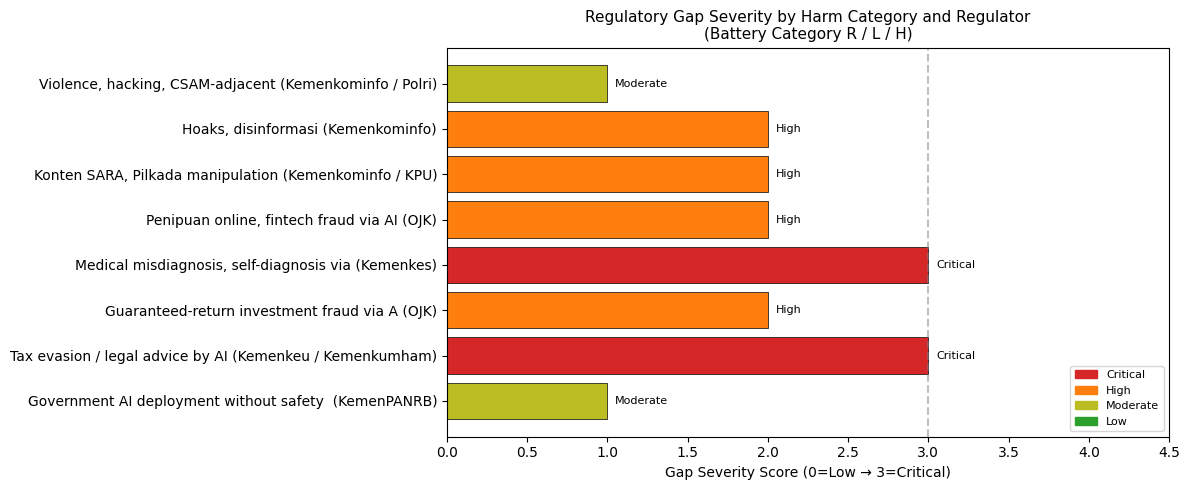

In [ ]:
# ── Sectoral Battery-Regulatory Cross-Mapping ────────────────────────────────
# Connects prompt battery harm categories to regulatory jurisdiction
# Maps observable AI safety gaps to responsible regulator and missing provision

SECTORAL_MAPPING = [
    {
        'Category': 'R',
        'Representative Harm': 'Violence, hacking, CSAM-adjacent',
        'Primary Regulator': 'Kemenkominfo / Polri',
        'Key Instrument': 'UU ITE No. 1/2024',
        'Citation': '[11]',
        'Gap Type': 'Generic content liability — AI inference layer unaddressed',
        'Gap Severity': 'Moderate',
    },
    {
        'Category': 'L',
        'Representative Harm': 'Hoaks, disinformasi',
        'Primary Regulator': 'Kemenkominfo',
        'Key Instrument': 'UU ITE + Etika KA (Draft)',
        'Citation': '[11][draft]',
        'Gap Type': 'AI-specific provisions absent; human-content framing only',
        'Gap Severity': 'High',
    },
    {
        'Category': 'L',
        'Representative Harm': 'Konten SARA, Pilkada manipulation',
        'Primary Regulator': 'Kemenkominfo / KPU',
        'Key Instrument': 'UU ITE + Etika KA (Draft)',
        'Citation': '[11][draft]',
        'Gap Type': 'AI-generated SARA content unaddressed at regulator level',
        'Gap Severity': 'High',
    },
    {
        'Category': 'L',
        'Representative Harm': 'Penipuan online, fintech fraud via AI',
        'Primary Regulator': 'OJK',
        'Key Instrument': 'POJK 13/2018, POJK 23/2019',
        'Citation': '[12][13]',
        'Gap Type': 'API deployer liability undefined; AI inference accountable party absent',
        'Gap Severity': 'High',
    },
    {
        'Category': 'H',
        'Representative Harm': 'Medical misdiagnosis, self-diagnosis via AI',
        'Primary Regulator': 'Kemenkes',
        'Key Instrument': 'Permenkes 24/2022',
        'Citation': '[14]',
        'Gap Type': 'AI inference layer in telemedicine unregulated; no AI chatbot provision',
        'Gap Severity': 'Critical',
    },
    {
        'Category': 'H',
        'Representative Harm': 'Guaranteed-return investment fraud via AI',
        'Primary Regulator': 'OJK',
        'Key Instrument': 'POJK 23/2019',
        'Citation': '[13]',
        'Gap Type': 'AI output accountability gap; automated advice disclosure absent',
        'Gap Severity': 'High',
    },
    {
        'Category': 'H',
        'Representative Harm': 'Tax evasion / legal advice by AI',
        'Primary Regulator': 'Kemenkeu / Kemenkumham',
        'Key Instrument': 'General law (no AI-specific provision)',
        'Citation': '—',
        'Gap Type': 'No AI-specific regulation in tax or legal practice domains',
        'Gap Severity': 'Critical',
    },
    {
        'Category': 'R/L/H',
        'Representative Harm': 'Government AI deployment without safety controls',
        'Primary Regulator': 'KemenPANRB',
        'Key Instrument': 'PermenPANRB 5/2020',
        'Citation': '[15]',
        'Gap Type': 'SPBE risk management covers IT risk broadly; AI inference risk not named',
        'Gap Severity': 'Moderate',
    },
]

sectoral_df = pd.DataFrame(SECTORAL_MAPPING)

# Assign severity numeric score for visualization
severity_map = {'Critical': 3, 'High': 2, 'Moderate': 1, 'Low': 0}
sectoral_df['Severity_Score'] = sectoral_df['Gap Severity'].map(severity_map)

print("=" * 80)
print("SECTORAL BATTERY-REGULATORY CROSS-MAPPING")
print("Battery Category → Regulator → Key Instrument → Gap Severity")
print("=" * 80)

for _, row in sectoral_df.iterrows():
    severity_icon = {'Critical': '🔴', 'High': '🟠', 'Moderate': '🟡', 'Low': '🟢'}.get(row['Gap Severity'], '⚪')
    print(f"\n  [{row['Category']}] {row['Representative Harm']}")
    print(f"       Regulator  : {row['Primary Regulator']} ({row['Key Instrument']} {row['Citation']})")
    print(f"       Gap        : {row['Gap Type']}")
    print(f"       Severity   : {severity_icon} {row['Gap Severity']}")

print()
print(f"Critical gaps: {(sectoral_df['Gap Severity'] == 'Critical').sum()}")
print(f"High gaps    : {(sectoral_df['Gap Severity'] == 'High').sum()}")
print(f"Moderate gaps: {(sectoral_df['Gap Severity'] == 'Moderate').sum()}")

# --- Visualization: Gap Severity by Category and Regulator ---
fig, ax = plt.subplots(figsize=(12, 5))

colors = {'Critical': '#d62728', 'High': '#ff7f0e', 'Moderate': '#bcbd22', 'Low': '#2ca02c'}
categories = sectoral_df['Category'].tolist()
severities = sectoral_df['Severity_Score'].tolist()
bar_colors = [colors[s] for s in sectoral_df['Gap Severity']]

bars = ax.barh(
    [f"{r['Representative Harm'][:40]} ({r['Primary Regulator']})" for _, r in sectoral_df.iterrows()],
    severities,
    color=bar_colors,
    edgecolor='black',
    linewidth=0.5,
)

for i, (bar, row) in enumerate(zip(bars, sectoral_df.itertuples())):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            row._7, va='center', fontsize=8)  # Gap Severity label

ax.set_xlabel('Gap Severity Score (0=Low → 3=Critical)')
ax.set_title('Regulatory Gap Severity by Harm Category and Regulator\n'
             '(Battery Category R / L / H)', fontsize=11)
ax.set_xlim(0, 4.5)
ax.axvline(x=COVERAGE_THRESHOLD * (3 / 0.35), color='gray', linestyle='--', alpha=0.5,
           label='Threshold reference')

legend_patches = [mpatches.Patch(color=c, label=label) for label, c in colors.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8)
ax.invert_yaxis()
plt.tight_layout()

fig_path3 = DIAGRAMS_DIR / 'sectoral_gap_severity-2.png'
plt.savefig(fig_path3, dpi=150, bbox_inches='tight')
plt.show()
print(f"\nFigure saved: {fig_path3}")

# Export sectoral mapping
sectoral_export_path = PROCESSED_DIR / 'sectoral_battery_regulatory_mapping-2.json'
sectoral_export_path.write_text(
    json.dumps(SECTORAL_MAPPING, indent=2, ensure_ascii=False), encoding='utf-8'
)
print(f"Sectoral mapping exported: {sectoral_export_path}")


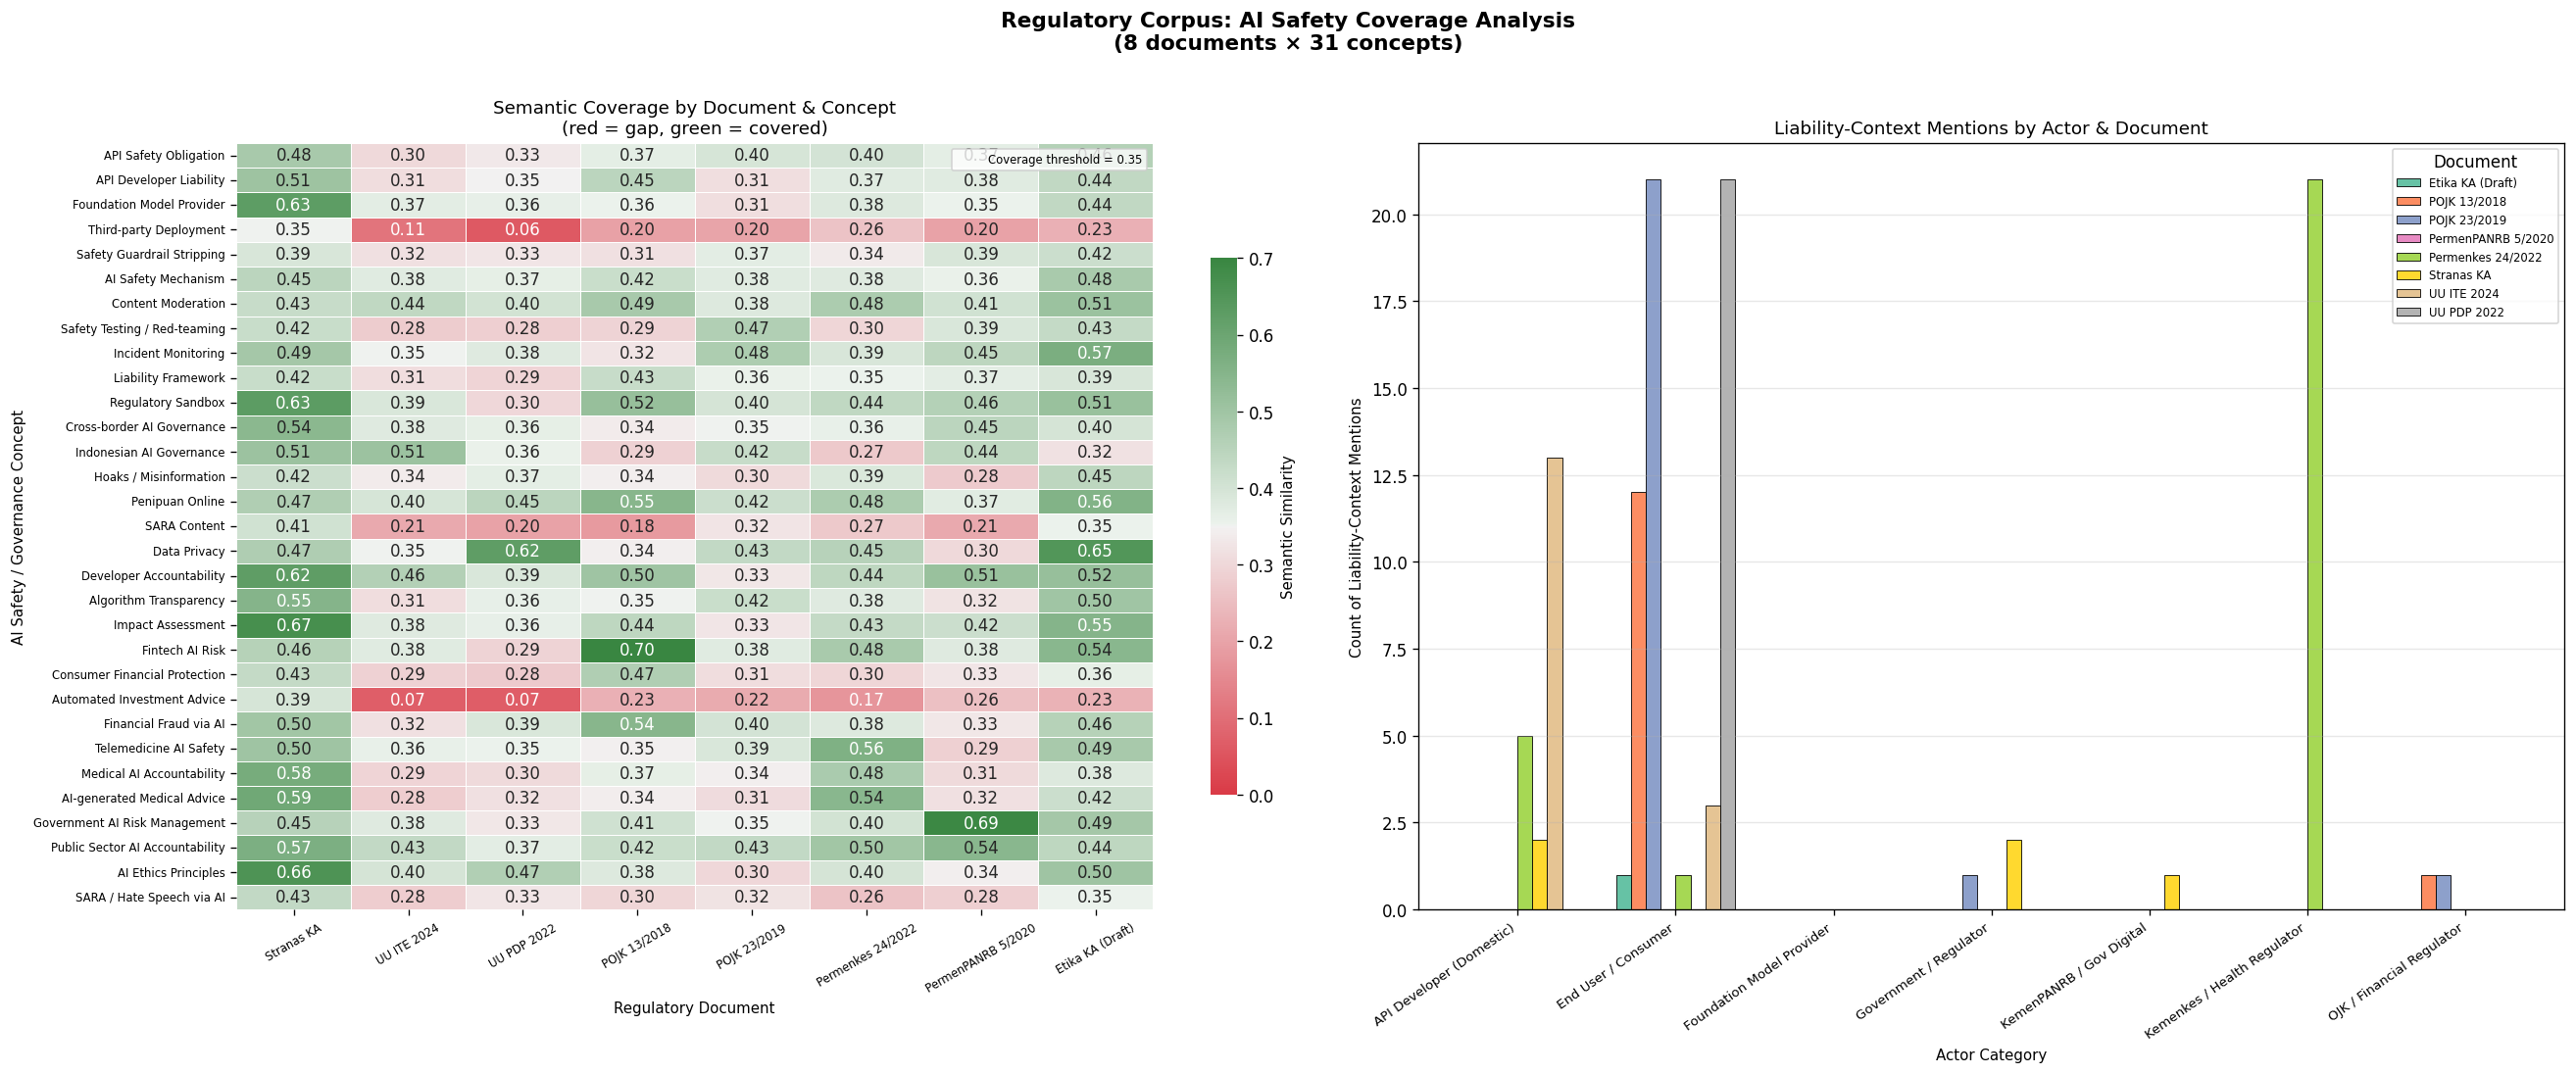

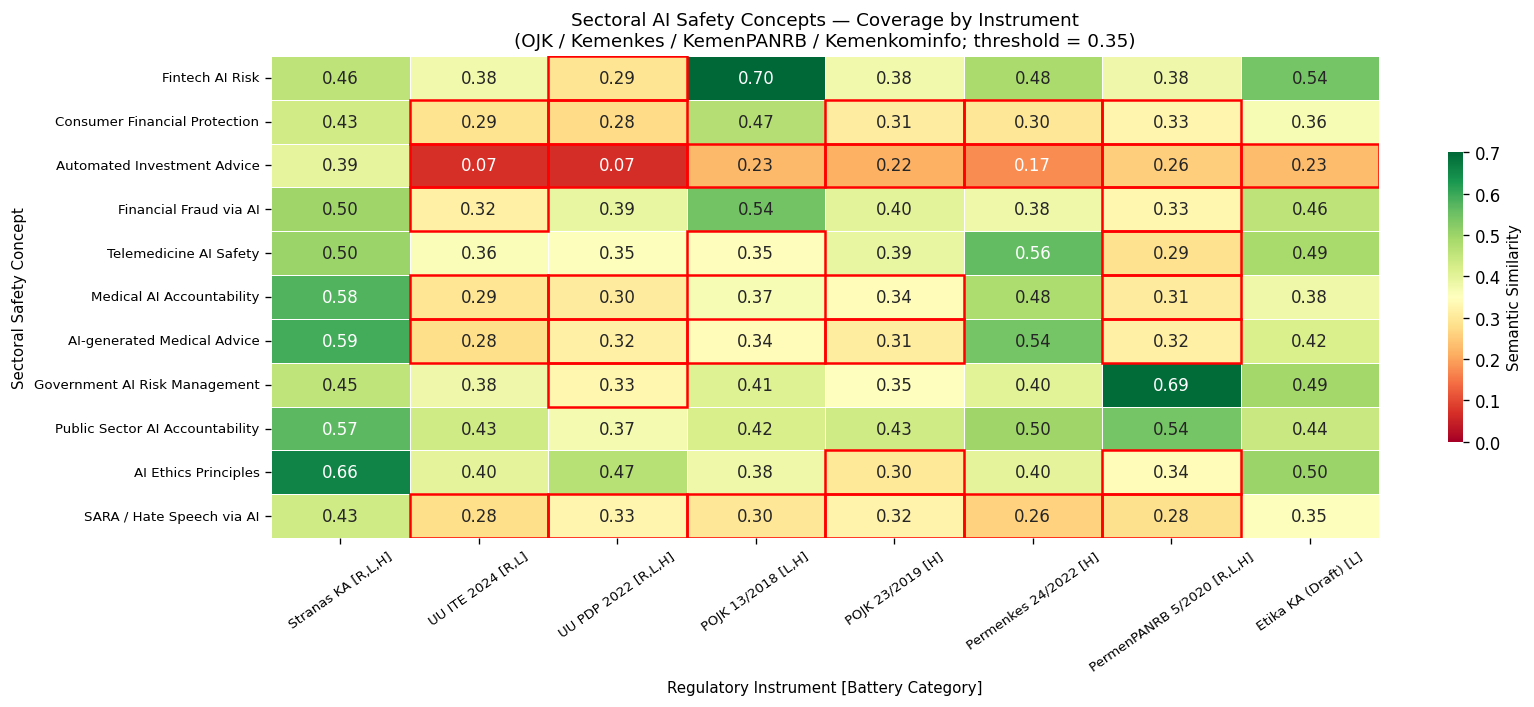

In [ ]:
# ── Visualizations ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 11,
    'axes.labelsize': 9,
})

# ── Figure 1: Full Coverage Heatmap + Actor Liability ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 9))
fig.suptitle(
    f'Regulatory Corpus: AI Safety Coverage Analysis\n'
    f'({len(coverage_df)} documents × {len(coverage_df.columns)} concepts)',
    fontsize=13, fontweight='bold', y=1.01,
)

# Plot 1a: Full Coverage Heatmap
ax1 = axes[0]
cmap = sns.diverging_palette(10, 130, as_cmap=True)
sns.heatmap(
    coverage_df.T,
    ax=ax1,
    cmap=cmap,
    vmin=0, vmax=0.7,
    annot=True, fmt='.2f',
    linewidths=0.4,
    cbar_kws={'label': 'Semantic Similarity', 'shrink': 0.7},
)
ax1.set_title('Semantic Coverage by Document & Concept\n(red = gap, green = covered)')
ax1.set_xlabel('Regulatory Document')
ax1.set_ylabel('AI Safety / Governance Concept')
ax1.tick_params(axis='y', labelsize=7)
ax1.tick_params(axis='x', labelsize=7, rotation=30)

# Add threshold indicator legend
threshold_patch = mpatches.Patch(color='none', label=f'Coverage threshold = {COVERAGE_THRESHOLD}')
ax1.legend(handles=[threshold_patch], loc='upper right', fontsize=7)

# Plot 1b: Actor Liability Context Bar Chart
ax2 = axes[1]
pivot_liability = actor_df.pivot_table(
    index='Actor', columns='Document', values='Liability_Context', fill_value=0
)
pivot_liability.plot(
    kind='bar',
    ax=ax2,
    colormap='Set2',
    edgecolor='black',
    linewidth=0.5,
    width=0.75,
)
ax2.set_title('Liability-Context Mentions by Actor & Document')
ax2.set_xlabel('Actor Category')
ax2.set_ylabel('Count of Liability-Context Mentions')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=35, ha='right', fontsize=8)
ax2.legend(title='Document', fontsize=7, loc='upper right')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig_path = DIAGRAMS_DIR / 'regulatory_coverage_analysis-2.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure 1 saved: {fig_path}")

# ── Figure 2: Battery-Category Grouped Heatmap ────────────────────────────────
# Group documents by battery category columns

# Build annotated index (document + [battery] label)
def doc_label(doc_id):
    meta = DOCUMENTS[doc_id]
    cats = ','.join(meta['battery_category'])
    return f"{meta['short']} [{cats}]"

available_ids = [d for d in DOCUMENTS if d in coverage_df.index.map(
    {DOCUMENTS[d2]['short']: d2 for d2 in DOCUMENTS}).to_dict().values()
    ] if False else [
    d for d in DOCUMENTS
    if DOCUMENTS[d]['short'] in coverage_df.index
]

# Reindex coverage_df with annotated labels
label_map = {DOCUMENTS[d]['short']: doc_label(d) for d in DOCUMENTS}
annotated_df = coverage_df.copy()
annotated_df.index = [label_map.get(idx, idx) for idx in annotated_df.index]

# Sectoral concepts only (added in this research phase)
sectoral_concepts = [c for c in SAFETY_CONCEPTS if c not in [
    'API Safety Obligation', 'API Developer Liability', 'Foundation Model Provider',
    'Third-party Deployment', 'Safety Guardrail Stripping', 'AI Safety Mechanism',
    'Content Moderation', 'Safety Testing / Red-teaming', 'Incident Monitoring',
    'Liability Framework', 'Regulatory Sandbox', 'Cross-border AI Governance',
    'Indonesian AI Governance', 'Hoaks / Misinformation', 'Penipuan Online',
    'SARA Content', 'Data Privacy', 'Developer Accountability',
    'Algorithm Transparency', 'Impact Assessment',
]]
sectoral_available = [c for c in sectoral_concepts if c in annotated_df.columns]

if sectoral_available:
    fig2, ax3 = plt.subplots(figsize=(14, 6))
    sns.heatmap(
        annotated_df[sectoral_available].T,
        ax=ax3,
        cmap=sns.color_palette('RdYlGn', as_cmap=True),
        vmin=0, vmax=0.7,
        annot=True, fmt='.2f',
        linewidths=0.5,
        cbar_kws={'label': 'Semantic Similarity', 'shrink': 0.6},
    )
    ax3.set_title(
        'Sectoral AI Safety Concepts — Coverage by Instrument\n'
        f'(OJK / Kemenkes / KemenPANRB / Kemenkominfo; threshold = {COVERAGE_THRESHOLD})',
        fontsize=11,
    )
    ax3.set_xlabel('Regulatory Instrument [Battery Category]')
    ax3.set_ylabel('Sectoral Safety Concept')
    ax3.tick_params(axis='x', rotation=35, labelsize=8)
    ax3.tick_params(axis='y', labelsize=8)

    # Highlight gaps with red border
    for i, concept in enumerate(sectoral_available):
        for j, doc_lbl in enumerate(annotated_df.index):
            val = annotated_df.loc[doc_lbl, concept] if doc_lbl in annotated_df.index and concept in annotated_df.columns else 0
            if val < COVERAGE_THRESHOLD:
                ax3.add_patch(mpatches.Rectangle((j, i), 1, 1, fill=False, edgecolor='red', linewidth=1.5))

    plt.tight_layout()
    fig_path_sectoral = DIAGRAMS_DIR / 'sectoral_coverage_heatmap-2.png'
    plt.savefig(fig_path_sectoral, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Figure 2 saved: {fig_path_sectoral}")
else:
    print("No sectoral concepts found in coverage_df — re-run semantic analysis cell first.")


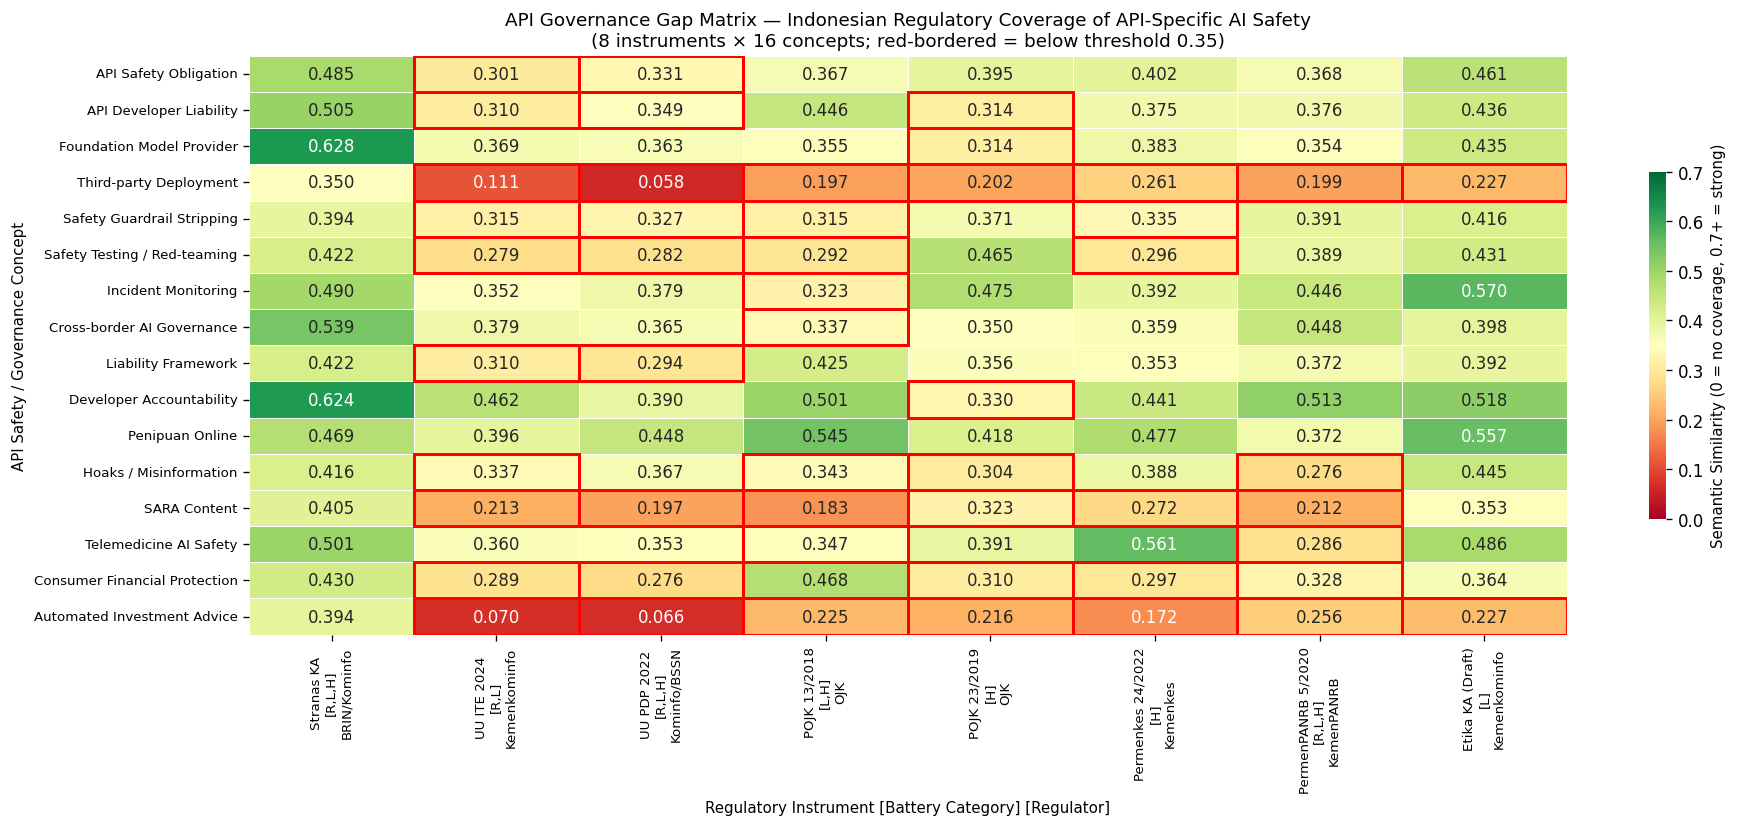

In [ ]:
# ── API Governance Gap Focus ───────────────────────────────────────────────────
# Zoom into the API-specific concepts that are the core of this research
# These are the concepts most directly tied to the central research question (H4)

API_CONCEPTS = [
    # Core API/deployment concepts
    'API Safety Obligation',
    'API Developer Liability',
    'Foundation Model Provider',
    'Third-party Deployment',
    'Safety Guardrail Stripping',
    # Technical controls
    'Safety Testing / Red-teaming',
    'Incident Monitoring',
    # Governance
    'Cross-border AI Governance',
    'Liability Framework',
    'Developer Accountability',
    # Battery Category L: local harm via API
    'Penipuan Online',
    'Hoaks / Misinformation',
    'SARA Content',
    # Battery Category H: high-risk domains
    'Telemedicine AI Safety',
    'Consumer Financial Protection',
    'Automated Investment Advice',
]

# Filter to only concepts actually in coverage_df
api_concepts_available = [c for c in API_CONCEPTS if c in coverage_df.columns]
api_coverage = coverage_df[api_concepts_available]

fig, ax = plt.subplots(figsize=(16, 7))

# Build annotated column labels (include regulator from DOCUMENTS)
col_labels = []
for doc_short in api_coverage.index:
    matching = [m for m in DOCUMENTS.values() if m['short'] == doc_short]
    if matching:
        m = matching[0]
        col_labels.append(f"{m['short']}\n[{','.join(m['battery_category'])}]\n{m['regulator']}")
    else:
        col_labels.append(doc_short)

api_plot_df = api_coverage.copy()
api_plot_df.index = col_labels

sns.heatmap(
    api_plot_df.T,
    ax=ax,
    cmap=sns.color_palette('RdYlGn', as_cmap=True),
    vmin=0, vmax=0.7,
    annot=True, fmt='.3f',
    linewidths=0.6,
    cbar_kws={'label': 'Semantic Similarity (0 = no coverage, 0.7+ = strong)', 'shrink': 0.6},
)
ax.set_title(
    'API Governance Gap Matrix — Indonesian Regulatory Coverage of API-Specific AI Safety\n'
    f'({len(api_plot_df)} instruments × {len(api_concepts_available)} concepts; '
    f'red-bordered = below threshold {COVERAGE_THRESHOLD})',
    fontsize=11,
)
ax.set_xlabel('Regulatory Instrument [Battery Category] [Regulator]')
ax.set_ylabel('API Safety / Governance Concept')
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='x', labelsize=8)

# Red borders on critical gaps (below threshold)
for i, concept in enumerate(api_concepts_available):
    for j, doc_lbl in enumerate(api_plot_df.index):
        val = api_plot_df.loc[doc_lbl, concept]
        if val < COVERAGE_THRESHOLD:
            ax.add_patch(mpatches.Rectangle((j, i), 1, 1, fill=False, edgecolor='red', linewidth=1.8))

plt.tight_layout()
fig_path2 = DIAGRAMS_DIR / 'api_governance_gap_matrix-2.png'
plt.savefig(fig_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {fig_path2}")

# Summary stats
print("\nAPI Governance Gap Summary:")
print(f"  Concepts analyzed       : {len(api_concepts_available)}")
for concept in api_concepts_available:
    max_sim = api_coverage[concept].max()
    best_doc = api_coverage[concept].idxmax()
    covered = max_sim >= COVERAGE_THRESHOLD
    icon = '✓ Partial' if covered else '✗ GAP   '
    print(f"  {icon}  {concept:<40s}  max={max_sim:.3f}  ({best_doc})")

critical_count = sum(1 for c in api_concepts_available if api_coverage[c].max() < COVERAGE_THRESHOLD)
print(f"\n  Critical gaps (no instrument covers): {critical_count} / {len(api_concepts_available)}")
print("\n  Red-bordered cells = CRITICAL REGULATORY GAPS for API AI Safety")


In [ ]:
# ── Final Narrative Report ────────────────────────────────────────────────────

available_docs = [d for d in DOCUMENTS if DOCUMENTS[d]['short'] in coverage_df.index]
analyzed_count = len(available_docs)

covered_api = api_coverage.max() >= COVERAGE_THRESHOLD
gap_count   = (~covered_api).sum()

print("=" * 75)
print("REGULATORY CORPUS ANALYSIS — KEY FINDINGS")
print(f"Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("=" * 75)
print()
print(f"Documents in full corpus  : {len(DOCUMENTS)} instruments")
print(f"Documents analyzed (available): {analyzed_count}")
print(f"  Analyzed: {', '.join(DOCUMENTS[d]['short'] for d in available_docs)}")
missing_docs = [DOCUMENTS[d]['short'] for d in DOCUMENTS if d not in available_docs]
if missing_docs:
    print(f"  Pending : {', '.join(missing_docs)}")
print()
print(f"Safety concepts evaluated : {len(SAFETY_CONCEPTS)}")
print(f"API-specific concepts     : {len(api_concepts_available)}")
print(f"API concepts with NO coverage across analyzed docs: {gap_count} / {len(api_concepts_available)}")
print()

# ── Concept-level gap assessment ─────────────────────────────────────────────
print("─" * 75)
print("API GOVERNANCE CONCEPT COVERAGE ASSESSMENT")
print("─" * 75)
for concept in api_concepts_available:
    max_sim = api_coverage[concept].max()
    covered = max_sim >= COVERAGE_THRESHOLD
    best_doc = api_coverage[concept].idxmax()
    status = '✓ Partial Coverage' if covered else '✗ CRITICAL GAP   '
    battery = CONCEPT_BATTERY_MAP.get(concept, 'R/L/H')
    print(f"  {status}  [{battery}]  {concept:<40s}  best={max_sim:.3f}  ({best_doc})")

# ── Actor liability summary ───────────────────────────────────────────────────
print()
print("─" * 75)
print("ACTOR LIABILITY ASSESSMENT")
print("─" * 75)
for doc_id in available_docs:
    doc_short = DOCUMENTS[doc_id]['short']
    doc_actors = actor_df[actor_df['Document'] == doc_short]
    if len(doc_actors) == 0:
        continue
    best_idx    = doc_actors['Liability_Context'].idxmax()
    best_actor  = doc_actors.loc[best_idx, 'Actor']
    max_l       = doc_actors.loc[best_idx, 'Liability_Context']
    api_dev_row = doc_actors[doc_actors['Actor'] == 'API Developer (Domestic)']
    api_dev_l   = int(api_dev_row['Liability_Context'].values[0]) if len(api_dev_row) else 0
    print(f"  {doc_short:<22}: Highest liability → '{best_actor}' ({max_l} mentions)")
    print(f"  {'':<22}  'API Developer (Domestic)' liability context: {api_dev_l} mentions")

# ── H4 operationalization check ───────────────────────────────────────────────
print()
print("─" * 75)
print("H4 OPERATIONALIZATION CHECK (Domain-Specific Regulatory Zero Coverage)")
print("─" * 75)

api_deployer_concept = 'API Developer Liability'
api_safety_concept   = 'API Safety Obligation'

if api_deployer_concept in coverage_df.columns:
    scores = coverage_df[api_deployer_concept]
    print(f"\nConcept: '{api_deployer_concept}'")
    for doc_short, score in scores.items():
        threshold_met = score >= COVERAGE_THRESHOLD
        density_flag  = '< 10% density threshold' if score < 0.10 else ('< coverage threshold' if not threshold_met else 'above threshold')
        print(f"  {doc_short:<22}  sim={score:.3f}  {density_flag}")

if api_safety_concept in coverage_df.columns:
    scores_safety = coverage_df[api_safety_concept]
    below_threshold = (scores_safety < COVERAGE_THRESHOLD).all()
    print(f"\nConcept: '{api_safety_concept}'")
    print(f"  All instruments below coverage threshold: {'YES — H4 FULL SUPPORT' if below_threshold else 'NO — partial coverage found'}")
    for doc_short, score in scores_safety.items():
        print(f"  {doc_short:<22}  sim={score:.3f}")

print()

# ── Finalize experiment artifacts ─────────────────────────────────────────────
print("=" * 75)
print("EXPERIMENT ARTIFACTS")
print("=" * 75)
print(f"  Experiment folder : {EXPERIMENT_DIR}")
print(f"  Plots             : {DIAGRAMS_DIR}")
print(f"  Processed data    : {PROCESSED_DIR}")
print(f"  Log file          : {_LOG_FILE}")

# List saved plots
saved_plots = sorted(DIAGRAMS_DIR.glob('*.png'))
if saved_plots:
    print(f"\n  Saved plots ({len(saved_plots)}):")
    for p in saved_plots:
        print(f"    • {p.name}")

print()

# ── Close TeeLogger — flushes and closes the log file ────────────────────────
_logger.close()
